

## Lab 2

Welcome to the second lab of the AIML!
In addition to implementing code, there will be questions that you must answer which relate to the lab and your implementation. Each question you will answer is preceded by a **'Question X'** header. Carefully read each question and provide you answer or code in the following textboxes with **'Answer:'** header. Your lab submission will be evaluated based on your answers to each of the questions and the implementation you provide.

# Every question is of 1 mark.

## Overview

In [75]:
from scipy.stats import ttest_1samp, ttest_ind, mannwhitneyu, levene, shapiro, wilcoxon, f_oneway
from scipy import stats
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

This module covers,

1) One sample and Two sample t-tests

2) ANOVA

3) Type I and Type II errors

4) Probabilty Distributions

5) Linear Regression

## Hypothesis Testing

The purpose of the test is to tell if there is any significant difference between two data sets.



## Question 1 

*A student is trying to decide between two GPUs. He want to use the GPU for his research to run Deep learning algorithms, so the only thing he is concerned with is speed.*

*He picks a Deep Learning algorithm on a large data set and runs it on both GPUs 15 times, timing each run in hours. Results are given in the below lists GPU1 and GPU2.*

Hint: You can import ttest function from scipy to perform t tests 

Given,

Null Hypothesis : There is no significant difference between data sets

Alternate Hypothesis : There is a significant difference

*Do two-sample testing and check whether to reject Null Hypothesis or not.*

#### Answer:

In [25]:
import pandas as pd
GPU1 = pd.DataFrame([11,9,10,11,10,12,9,11,12,9,11,12,9,10,9])
GPU2 = pd.DataFrame([11,13,10,13,12,9,11,12,12,11,12,12,10,11,13])

Performing shapiro and levenes test to confirm assumptions of Normality & Equal Variances

In [26]:
# Performing shapiro and levenes test to confirm assumptions of Normality & Equal Variances
# Shapiro Test
# Null Hypothesis - Data is normally distributed
# Alternate Hypothesis - Data is not normally distributed
stat, p = shapiro(GPU1)
print('Statistics=%.3f, p=%.3f' % (stat, p))
# interpret
alpha = 0.05
if p > alpha:
    print('GPU1 Data is normally distributed')
else:
    print('GPU1 Data is NOT normally distributed, need to use Mann-Whitney U-Test')

Statistics=0.854, p=0.020
GPU1 Data is NOT normally distributed, need to use Mann-Whitney U-Test


Since GPU1 is not normally distributed, using Mann-Whitney U-Test

In [27]:
# two-sample Mann-Whitney U-Test
# null hypothesis: the two groups have the same median
t_statistic, p_value = mannwhitneyu(GPU1, GPU2)
print('t_statistic=%.3f, p_value=%.3f' % (t_statistic, p_value))

t_statistic=57.000, p_value=0.010


# Answer 1

Since p-value based on Mann-Whitney U-Test of 0.010 is less than designated aplha value of 0.05, we reject the null hypothesis - There is a significant difference between speeds of two GPUs GPU1 and GPU2

## Question 2 



He is trying a third GPU which is GPU3.

In [30]:
GPU3 = pd.DataFrame([9,10,9,11,10,13,12,9,12,12,13,12,13,10,11])

#Assumption: Both the datasets (GPU1 & GPU 3) are random, independent, parametric & normally distributed

*Do two-sample testing and check whether there is significant differene between speeds of two GPUs GPU1 and GPU3.*

#### Answer:

Given the assumption provided, performing two-sample t-test without performing shapiro and levenes test to confirm assumptions of Normality & Equal Variances

In [32]:
# two-sample t-test
# null hypothesis: the two groups have the same mean
t_statistic, p_value = ttest_ind(GPU1, GPU3)
print('t_statistic=%.3f, p_value=%.3f' % (t_statistic, p_value))

t_statistic=-1.499, p_value=0.145


# Answer 2

Since p-value based on two-sample t-test of 0.145 is more than designated aplha value of 0.05, we do not reject the null hypothesis - There is NO significant difference between speeds of two GPUs GPU1 and GPU3

### ANOVA

## Question 3 

If you need to compare more than two data sets at a time, an ANOVA is your best bet. 

*The results from three experiments with overlapping 95% confidence intervals are given below, and we want to confirm that the results for all three experiments are not significantly different.*

#Assumption: All the 3 datasets (e1,e2 & e3) are random, independent, parametric & normally distributed
But before conducting ANOVA, test equality of variances (using Levene's test) is satisfied or not. If not, then mention that we cannot depend on the result of ANOVA

In [34]:
import pandas as pd
e1 = pd.DataFrame([1.595440,1.419730,0.000000,0.000000])
e2 = pd.DataFrame([1.433800,2.079700,0.892139,2.384740])
e3 = pd.DataFrame([0.036930,0.938018,0.995956,1.006970])

Hint - You can use stats.levene function and stats.f_oneway function.

#### Answer:

In [37]:
# For checking equality of variance between groups
# Null Hypothesis: Variances are equal
statistic, p_value = levene(e1,e2,e3)
print('statistic=%.3f, p_value=%.3f' % (t_statistic, p_value))

statistic=-1.499, p_value=0.123


Equality of variances (using Levene's test) is satisfied, proceeding with ANOVA testing

In [40]:
# One-way ANOVA test as the data for each group is numeric
f, p = f_oneway(e1,e2,e3)
 
print ('One-way ANOVA')
print ('=============')
 
print ('F value:', f)
print ('P value:', p, '\n')

One-way ANOVA
F value: [2.51357623]
P value: [0.13574645] 



# Answer 3

Since p-value>0.05 , we say that means for e1, e2 and e3 and not significantly different

## Question 4 

*In one or two sentences explain about **TypeI** and **TypeII** errors.*

## Answer 4:

Type 1 Error is rejecting the null hypothesis when it's is actually true and Type 2 error is failing to reject the null hypothesis when alternative is actually true. By defining significance level/alpha value at, say, 0.05, we ensure that Type 1 Error doesn't happen more than 5% times 

# Question 5
You are a manager of a chinese restaurant. You want to determine whether the waiting time to place an order has changed in the past month from its previous population mean value of 4.5 minutes. 
State the null and alternative hypothesis.

## Answer 5

**Null hypothesis:** Mean of waiting time to place an order is 4.5 minutes

**Alternative hypothesis:** Mean of waiting time to place an order is not 4.5

# Question 6 
Get the binomial distribution with n = 10, p = .7 and k = [0, 1, 2, 3, 4, 5, 6, 7]

Hint - Use stats.binom.pmf() function for this.


## Answer 6

In [45]:
n = 10
p = 0.7
k = [0, 1, 2, 3, 4, 5, 6, 7]
binomial = stats.binom.pmf(k, n, p)
binomial

array([5.90490000e-06, 1.37781000e-04, 1.44670050e-03, 9.00169200e-03,
       3.67569090e-02, 1.02919345e-01, 2.00120949e-01, 2.66827932e-01])

# Question 7 
Plot the distribution created in the above question.

## Answer 7

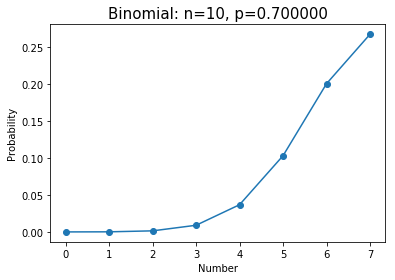

In [47]:
import matplotlib.pyplot as plt
plt.plot(k, binomial, 'o-')
plt.title('Binomial: n=%i, p=%2f' % (n,p), fontsize=15)
plt.xlabel('Number')
plt.ylabel('Probability')
plt.show()

# Linear Regression


# Simple Linear Regression

Here we will try to see that if we can make a regression model to predict one column of a dataset by the use of other coloumn.

## Dataset

Population of U.S. Cities

### Description
The bigcity data frame has 49 rows and 2 columns.

The measurements are the population (in 1000's) of 49 U.S. cities in 1920 and 1930. The 49 cities are a random sample taken from the 196 largest cities in 1920.

### Format
This data frame contains the following columns:

`u`
The 1920 population.

`x`
The 1930 population.

There is one unnamed column also in this dataset. Please remove and ignore that coloumn.

Source

The data were obtained from

Cochran, W.G. (1977) Sampling Techniques. Third edition. John Wiley

References

Davison, A.C. and Hinkley, D.V. (1997) Bootstrap Methods and Their Application. Cambridge University Press.

# Question 8 
Read the dataset given in file named 'bigcity.csv'.

## Answer 8

In [50]:
# read the data
df = pd.read_csv("bigcity.csv")
df.head()

,Unnamed: 0,u,x
0,1,138,143
1,2,93,104
2,3,61,69
3,4,179,260
4,5,48,75


# Question 9 - Transform the dataset 
Find the number of rows in given dataset and separate the input(u column)  and target variables(x column) into X and Y.

Remove the unnamed coloumn.

Hint: You can shape function to get the size of the dataframe


## Answer 9

In [52]:
# Find the number of rows in given dataset
df.shape

(49, 3)

There are 49 rows in the given dataset

In [68]:
# separate the input(u column) and target variables(x column) into X and Y
X = df['u'].values.reshape(-1,1)
Y = df['x'].values.reshape(-1,1)

In [61]:
# Remove the unnamed coloumn
df = df.loc[:,["u","x"]]
df.head()

,u,x
0,138,143
1,93,104
2,61,69
3,179,260
4,48,75


## Question 10 - Check the dataset for any missing values and also print out the correlation matrix 

You can use .isna() and .corr() functions to check NA's and correlation in the dataframe respectively

## Answer 10

In [62]:
# Check the dataset for any missing values
missing_u = df['u'].isnull().sum()
missing_x = df['x'].isnull().sum()
print("Number of missing values in column 'u': {} and in column 'x': {}".format(missing_u, missing_x))

Number of missing values in column 'u': 0 and in column 'x': 0


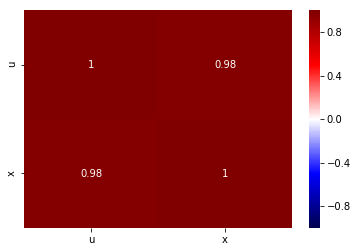

In [64]:
## print out the correlation
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, cmap='seismic')

### The high correlation betwwen u and x indicates that the variable u is a good predictor of variable x

# Question 11 - Split data into train, test sets 
Divide the data into training and test sets with 80-20 split using scikit-learn. Print the shapes of training and test feature sets.*

Check: train_test_split function

## Answer 11

In [95]:
from sklearn.model_selection import train_test_split
# create training and testing vars
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
print('Train-test split validation:')
print('Training: X Shape-', X_train.shape, 'Y Shape-', y_train.shape)
print('Testing: X Shape-', X_test.shape, 'Y Shape-', y_test.shape)

Train-test split validation:
Training: X Shape- (39, 1) Y Shape- (39, 1)
Testing: X Shape- (10, 1) Y Shape- (10, 1)


# Question 12 - Find coefficients & intercept
Estimate the coefficients b0 and b1 using scikit-learn.

## Answer 12

In [112]:
# Create linear regression object
regr = linear_model.LinearRegression()

# Train the model using the training sets
regr.fit(X_train, y_train)

# Estimate the coefficients b0
b0 = regr.intercept_[0]
print('Estimated intercept/b0 coefficient:', b0)

# Estimate the coefficients b1
b1 = regr.coef_[0][0]
print('Estimated b1 coefficient:', b1)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Estimated intercept/b0 coefficient: 9.571154371312304
Estimated b1 coefficient: 1.1646553690464534


Check: coef_ and intercept_ functions can help you get coefficients & intercept

# Question 13 - Linear Relationship between feature and target 
Plot the line with b1 and b0 as slope and y-intercept.

Hint - y = mx + c, plot y

## Answer 13

In [113]:
X_train_df = pd.DataFrame(X_train)
y_train_df = pd.DataFrame(y_train)
plot_df = pd.concat([X_train_df, y_train_df], axis=1)
plot_df.columns = ['x_train', 'y_train']
plot_df['predicted_y'] = b0 + (b1 * plot_df['x_train'])
plot_df.head()

,x_train,y_train,predicted_y
0,46,53,63.145301
1,36,46,51.498748
2,67,67,87.603064
3,136,139,167.964285
4,36,54,51.498748


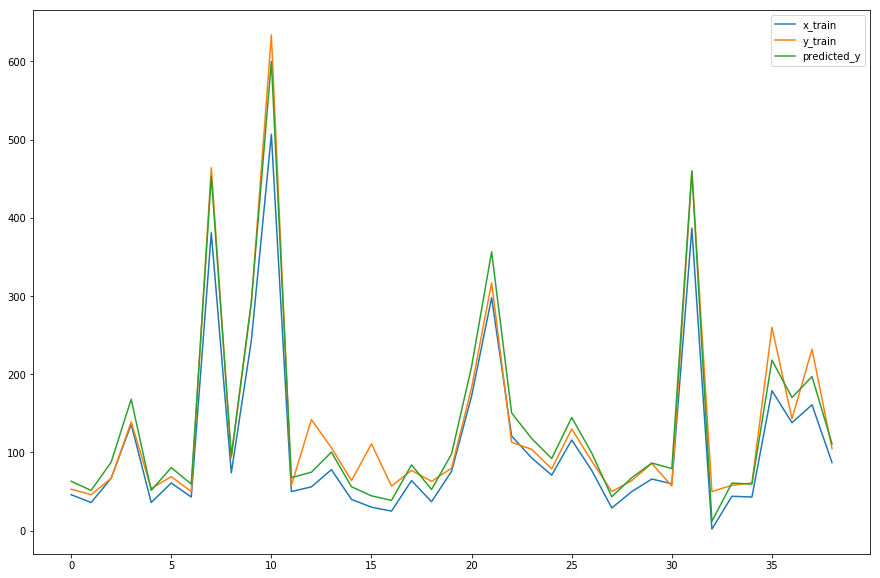

In [117]:
plot_df.plot(kind='line', figsize=(15, 10))

# Question 14 - Evaluation of model with scikit-learn 
Validate the model with Root Mean Squares error and R^2 score using scikit-learn. RMSE and R2 for test data and prediction

Hint: You can import mean_squared_error function & r2 (R square) from sklearn.metrics. Performing root operation over mean square error over mean square error gives you root mean square error

## Answer 14

In [97]:
y_pred = regr.predict(X_test)
from math import sqrt
mse = mean_squared_error(y_test, y_pred)
rmse = sqrt(mse)
r2 = r2_score(y_test, y_pred)  
print("RMSE and R2 for test data and prediction is {} and {} respectively".format(r2,rmse))

RMSE and R2 for test data and prediction is 0.92536721776934 and 18.71070389373071 respectively


## Question 15 - Calculate the accuracy of the model for both training and test data set 

### Hint: .score() function 

## Answer 15

In [98]:
y_pred_train = regr.predict(X_train)
acc_train = regr.score(y_train, y_pred_train)
acc_test = regr.score(y_test, y_pred)
print("Accuracy of the model for training and test data set is {} and {} respectively".format(acc_train,acc_test))

Accuracy of the model for training and test data set is 0.8609496638413379 and 0.9184241386370827 respectively
